# PHÂN TÍCH LỖI CHUYÊN SÂU (ERROR ANALYSIS)
## Phân Tích Lỗi Định Lượng, Định Tính & Độ Trễ Suy Luận
**Khóa luận tốt nghiệp: Phát hiện khuyết tật trên bo mạch PCB sử dụng mô hình học sâu YOLOv8n-P2**

---

### Mục tiêu của Toàn Bộ Giai Đoạn Phân Tích Lỗi:
1. **Thiết lập môi trường và nạp dữ liệu (Phase 7)**:
   - Đối sánh trực tiếp 2 cấu hình chủ chốt: Baseline $B_0$ (YOLOv8n tiêu chuẩn, $\tau = 0.25$) và Đề xuất $Proposed$ (YOLOv8n-P2, $\tau = 0.13$).
   - Tuân thủ nghiêm ngặt nguyên tắc: **Không chọn lại threshold, không train lại model**.
2. **Sinh / đọc tập kiểm thử predictions và ground truth (Phase 8)**:
   - Tái sử dụng prediction cache để đảm bảo tính nhất quán tuyệt đối.
   - Xuất dữ liệu chuẩn hóa: `results/B0/test_predictions.csv`, `results/Proposed/test_predictions.csv`, `results/test_ground_truth_boxes.csv`.
3. **Ma trận nhầm lẫn 6 lớp + Background (Phase 9)**:
   - Ghép cặp IoU $\ge 0.5$, phân loại chi tiết True Positive, Misclassification, False Negative (bỏ sót vào Background), False Positive (báo giả từ Background).
   - Xuất bảng số liệu và heatmap trực quan 300 DPI cho $B_0$ và $Proposed$.
4. **Phân tích False Negative theo Lớp $\times$ Size Bin (Phase 10)**:
   - Thống kê khuyết tật bị bỏ sót theo kích thước: small, medium, large.
   - So sánh $\Delta_{FN} = FN_{Proposed} - FN_{B0}$ để định lượng mức giảm bỏ sót lỗi.
5. **Chỉ số lỗi chí mạng Critical FN Rate cho 4 cấu hình (Phase 11)**:
   - Tổng hợp $R_{critical}$, $Critical\_FN\_rate$, $Board\_FA$, $Board\_FR$ từ `ablation_master.csv`.
   - Trực quan hóa biểu đồ 4 cấu hình để trả lời trực tiếp cho RQ3 và RQ4.
6. **Thư viện trực quan hóa lỗi bỏ sót FN Gallery (Phase 12)**:
   - Trích xuất 18 ảnh test tiêu biểu có khuyết tật bị bỏ sót bởi mô hình đề xuất.
   - Phân loại nguyên nhân thành 6 nhóm chuẩn mực làm cơ sở luận giải định tính cho Chương 5.


In [1]:
import os
import sys
import json
import yaml
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont

# Thiết lập đường dẫn gốc workspace chuẩn xác
ROOT = Path.cwd()
if ROOT.name == "scripts":
    ROOT = ROOT.parent
elif (ROOT / "scripts").is_dir():
    pass

# Đảm bảo các thư mục kết quả tồn tại
(ROOT / "results" / "Proposed").mkdir(parents=True, exist_ok=True)
(ROOT / "results" / "B0").mkdir(parents=True, exist_ok=True)
(ROOT / "results" / "csv").mkdir(parents=True, exist_ok=True)
(ROOT / "results" / "png").mkdir(parents=True, exist_ok=True)
(ROOT / "results" / "fn_gallery").mkdir(parents=True, exist_ok=True)

# Cấu hình thẩm mỹ đồ thị chuẩn học thuật
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 15

print("=" * 80)
print(f"Đường dẫn gốc Workspace: {ROOT}")
print(f"Python runtime: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__} | Matplotlib: {plt.matplotlib.__version__}")
print("=" * 80)


Đường dẫn gốc Workspace: /Users/Project/kltn-pcb
Python runtime: 3.13.5
Pandas: 2.2.3 | NumPy: 2.1.3 | Matplotlib: 3.10.0


---
## PHASE 7 — Setup & Xác Thực 6 Nguồn Dữ Liệu
Kiểm tra tính toàn vẹn của 6 nguồn dữ liệu đầu vào và khóa cứng 2 cấu hình $B_0$ và $Proposed$.


In [2]:
# 1. Đọc results/ablation_master.csv
ABLATION_CSV = ROOT / "results" / "ablation_master.csv"
if not ABLATION_CSV.exists() and (ROOT / "results" / "csv" / "ablation_master.csv").exists():
    ABLATION_CSV = ROOT / "results" / "csv" / "ablation_master.csv"
assert ABLATION_CSV.is_file(), f"LỖI: Thiếu tệp {ABLATION_CSV}"
df_ablation = pd.read_csv(ABLATION_CSV)

# 2. Đọc configs/threshold.yaml
THRESH_YAML = ROOT / "configs" / "threshold.yaml"
assert THRESH_YAML.is_file(), f"LỖI: Thiếu tệp {THRESH_YAML}"
with open(THRESH_YAML, "r", encoding="utf-8") as f:
    thresh_cfg = yaml.safe_load(f)

# 3. Đọc data/data.yaml
DATA_YAML = ROOT / "data" / "data.yaml"
assert DATA_YAML.is_file(), f"LỖI: Thiếu tệp {DATA_YAML}"
with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

# 4. Đọc data/splits/test.txt
TEST_TXT = ROOT / "data" / "splits" / "test.txt"
assert TEST_TXT.is_file(), f"LỖI: Thiếu tệp {TEST_TXT}"
with open(TEST_TXT, "r", encoding="utf-8") as f:
    test_image_paths = [line.strip() for line in f if line.strip()]

# 5 & 6. Kiểm tra trọng số mô hình best.pt
WEIGHTS_B0 = ROOT / "runs" / "B0_100ep" / "weights" / "best.pt"
WEIGHTS_B1 = ROOT / "runs" / "B1_100ep" / "weights" / "best.pt"
assert WEIGHTS_B0.is_file(), f"LỖI: Thiếu checkpoint {WEIGHTS_B0}"
assert WEIGHTS_B1.is_file(), f"LỖI: Thiếu checkpoint {WEIGHTS_B1}"

# Trích xuất tham số ngưỡng và danh mục lớp
tau_b0_val = thresh_cfg.get("tau", {}).get("B0", 0.20)
tau_b1_val = thresh_cfg.get("tau", {}).get("B1", 0.13)
critical_classes = thresh_cfg.get("critical_classes", ["open_circuit", "short"])
classes_list = data_cfg.get("names", [])
if isinstance(classes_list, dict):
    classes_list = [classes_list[i] for i in sorted(classes_list.keys())]

print("=" * 80)
print("XÁC THỰC THÀNH CÔNG 6 NGUỒN DỮ LIỆU ĐẦU VÀO CHO ERROR ANALYSIS:")
print("=" * 80)
print(f"1. [EXISTS] Ablation Master CSV: {ABLATION_CSV.relative_to(ROOT)} ({len(df_ablation)} cấu hình)")
print(f"2. [EXISTS] Threshold YAML    : {THRESH_YAML.relative_to(ROOT)} (tau_B0={tau_b0_val}, tau_B1={tau_b1_val})")
print(f"3. [EXISTS] Data YAML         : {DATA_YAML.relative_to(ROOT)} ({len(classes_list)} lớp: {classes_list})")
print(f"4. [EXISTS] Test Split TXT    : {TEST_TXT.relative_to(ROOT)} ({len(test_image_paths)} ảnh test)")
print(f"5. [EXISTS] Weights B0        : {WEIGHTS_B0.relative_to(ROOT)} ({WEIGHTS_B0.stat().st_size:,} bytes)")
print(f"6. [EXISTS] Weights B1/Prop   : {WEIGHTS_B1.relative_to(ROOT)} ({WEIGHTS_B1.stat().st_size:,} bytes)")
print("=" * 80)


XÁC THỰC THÀNH CÔNG 6 NGUỒN DỮ LIỆU ĐẦU VÀO CHO ERROR ANALYSIS:
1. [EXISTS] Ablation Master CSV: results/ablation_master.csv (4 cấu hình)
2. [EXISTS] Threshold YAML    : configs/threshold.yaml (tau_B0=0.2, tau_B1=0.13)
3. [EXISTS] Data YAML         : data/data.yaml (6 lớp: ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper'])
4. [EXISTS] Test Split TXT    : data/splits/test.txt (480 ảnh test)
5. [EXISTS] Weights B0        : runs/B0_100ep/weights/best.pt (6,237,866 bytes)
6. [EXISTS] Weights B1/Prop   : runs/B1_100ep/weights/best.pt (6,221,136 bytes)


---
## PHASE 8 — Sinh / Đọc Prediction Test Cho Error Analysis
Xây dựng tập dự đoán chuẩn hóa cho $B_0$ (ngưỡng $\tau=0.25$) và $Proposed$ (ngưỡng $\tau=0.13$), đồng thời chuẩn hóa Ground Truth tập kiểm thử.


In [3]:
# 1. Đọc và chuẩn hóa Ground Truth tập kiểm thử (test set)
GT_SRC = ROOT / "results" / "csv" / "test_ground_truth.csv"
if not GT_SRC.is_file() and (ROOT / "results" / "test_ground_truth.csv").is_file():
    GT_SRC = ROOT / "results" / "test_ground_truth.csv"
assert GT_SRC.is_file(), f"LỖI: Không tìm thấy tệp ground truth nguồn {GT_SRC}"

df_gt_all = pd.read_csv(GT_SRC)
gt_cols = ["image_path", "image_name", "class_id", "class_name", "xmin", "ymin", "xmax", "ymax", "area_px", "size_bin"]
df_gt_boxes = df_gt_all[gt_cols].copy()

# Lưu results/test_ground_truth_boxes.csv và mirror sang results/csv/
GT_OUT_1 = ROOT / "results" / "test_ground_truth_boxes.csv"
GT_OUT_2 = ROOT / "results" / "csv" / "test_ground_truth_boxes.csv"
df_gt_boxes.to_csv(GT_OUT_1, index=False)
df_gt_boxes.to_csv(GT_OUT_2, index=False)
print(f"✅ Đã lưu Ground Truth Boxes: {GT_OUT_1.relative_to(ROOT)} ({len(df_gt_boxes):,} boxes)")

# 2. Tái sử dụng Prediction Cache từ evaluation
PRED_CACHE_B0 = ROOT / "results" / "B0" / "test_predictions_for_eval.csv"
PRED_CACHE_B1 = ROOT / "results" / "B1" / "test_predictions_for_eval.csv"

assert PRED_CACHE_B0.is_file(), f"LỖI: Không tìm thấy prediction cache B0 tại {PRED_CACHE_B0}"
assert PRED_CACHE_B1.is_file(), f"LỖI: Không tìm thấy prediction cache B1 tại {PRED_CACHE_B1}"

df_raw_b0 = pd.read_csv(PRED_CACHE_B0)
df_raw_b1 = pd.read_csv(PRED_CACHE_B1)

# Lọc ngưỡng đánh giá bất biến: B0 (tau=0.25), Proposed (tau=0.13)
pred_cols = ["image_path", "image_name", "class_id", "class_name", "confidence", "xmin", "ymin", "xmax", "ymax"]

df_pred_b0 = df_raw_b0[df_raw_b0["confidence"] >= 0.25][pred_cols].copy().reset_index(drop=True)
df_pred_prop = df_raw_b1[df_raw_b1["confidence"] >= tau_b1_val][pred_cols].copy().reset_index(drop=True)

# Lưu predictions
PRED_B0_OUT = ROOT / "results" / "B0" / "test_predictions.csv"
PRED_PROP_OUT = ROOT / "results" / "Proposed" / "test_predictions.csv"
df_pred_b0.to_csv(PRED_B0_OUT, index=False)
df_pred_prop.to_csv(PRED_PROP_OUT, index=False)

print(f"✅ Đã lưu B0 Predictions      : {PRED_B0_OUT.relative_to(ROOT)} ({len(df_pred_b0):,} boxes, tau=0.25)")
print(f"✅ Đã lưu Proposed Predictions: {PRED_PROP_OUT.relative_to(ROOT)} ({len(df_pred_prop):,} boxes, tau={tau_b1_val})")
print(f"Tỉ lệ phát hiện / Ground Truth: B0={len(df_pred_b0)/len(df_gt_boxes):.2f}x | Proposed={len(df_pred_prop)/len(df_gt_boxes):.2f}x")


✅ Đã lưu Ground Truth Boxes: results/test_ground_truth_boxes.csv (2,412 boxes)
✅ Đã lưu B0 Predictions      : results/B0/test_predictions.csv (4,352 boxes, tau=0.25)
✅ Đã lưu Proposed Predictions: results/Proposed/test_predictions.csv (7,616 boxes, tau=0.13)
Tỉ lệ phát hiện / Ground Truth: B0=1.80x | Proposed=3.16x


---
## PHASE 9 — Ma Trận Nhầm Lẫn 6 Lớp + Background
Xây dựng thuật toán ghép cặp (IoU $\ge 0.5$) chuẩn xác giữa Ground Truth và Dự đoán:
1. **GT match đúng class**: Ghi nhận True Positive (ô `[class, class]`).
2. **GT match sai class**: Ghi nhận Lỗi phân loại (ô `[true_class, pred_class]`).
3. **GT không được match**: Ghi nhận Bỏ sót (False Negative, ô `[true_class, background]`).
4. **Prediction không được match**: Ghi nhận Báo giả (False Positive, ô `[background, pred_class]`).


In [4]:
ALL_LABELS = classes_list + ["background"]
label2idx = {lbl: i for i, lbl in enumerate(ALL_LABELS)}

def compute_box_iou(boxA, boxB):
    # Tinh Intersection over Union (IoU) giua 2 bounding box [xmin, ymin, xmax, ymax]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interW = max(0.0, xB - xA)
    interH = max(0.0, yB - yA)
    interArea = interW * interH
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    unionArea = boxAArea + boxBArea - interArea
    if unionArea <= 0:
        return 0.0
    return interArea / unionArea

def generate_confusion_matrix(df_gt, df_pred, iou_thresh=0.5):
    # Tinh ma tran nham lan 7x7 theo quy tac ghep cap greedy IoU >= 0.5
    n_labels = len(ALL_LABELS)
    cm = np.zeros((n_labels, n_labels), dtype=int)
    
    img_names = sorted(set(df_gt["image_name"].unique()).union(set(df_pred["image_name"].unique())))
    gt_grouped = {k: v for k, v in df_gt.groupby("image_name")}
    pred_grouped = {k: v for k, v in df_pred.groupby("image_name")}
    
    bg_idx = label2idx["background"]
    
    for img in img_names:
        gts = gt_grouped.get(img, pd.DataFrame()).to_dict("records")
        preds = pred_grouped.get(img, pd.DataFrame()).to_dict("records")
        preds = sorted(preds, key=lambda x: x.get("confidence", 1.0), reverse=True)
        
        gt_matched = [False] * len(gts)
        pred_matched = [False] * len(preds)
        
        # Bước 1: Ưu tiên match cùng class với IoU >= iou_thresh
        for p_idx, p in enumerate(preds):
            p_box = [p["xmin"], p["ymin"], p["xmax"], p["ymax"]]
            best_iou = -1.0
            best_g_idx = -1
            for g_idx, g in enumerate(gts):
                if gt_matched[g_idx]:
                    continue
                if g["class_name"] == p["class_name"]:
                    iou = compute_box_iou(p_box, [g["xmin"], g["ymin"], g["xmax"], g["ymax"]])
                    if iou >= iou_thresh and iou > best_iou:
                        best_iou = iou
                        best_g_idx = g_idx
            if best_g_idx != -1:
                gt_matched[best_g_idx] = True
                pred_matched[p_idx] = True
                c_idx = label2idx[p["class_name"]]
                cm[c_idx, c_idx] += 1
                
        # Bước 2: Match các dự đoán còn lại với GT khác class có IoU >= iou_thresh (nhầm class)
        for p_idx, p in enumerate(preds):
            if pred_matched[p_idx]:
                continue
            p_box = [p["xmin"], p["ymin"], p["xmax"], p["ymax"]]
            best_iou = -1.0
            best_g_idx = -1
            for g_idx, g in enumerate(gts):
                if gt_matched[g_idx]:
                    continue
                iou = compute_box_iou(p_box, [g["xmin"], g["ymin"], g["xmax"], g["ymax"]])
                if iou >= iou_thresh and iou > best_iou:
                    best_iou = iou
                    best_g_idx = g_idx
            if best_g_idx != -1:
                gt_matched[best_g_idx] = True
                pred_matched[p_idx] = True
                g_c_idx = label2idx[gts[best_g_idx]["class_name"]]
                p_c_idx = label2idx[p["class_name"]]
                cm[g_c_idx, p_c_idx] += 1
                
        # Bước 3: GT không được match -> True Class nhầm thành Background (False Negative)
        for g_idx, g in enumerate(gts):
            if not gt_matched[g_idx]:
                g_c_idx = label2idx[g["class_name"]]
                cm[g_c_idx, bg_idx] += 1
                
        # Bước 4: Pred không được match -> Background báo nhầm thành Pred Class (False Positive)
        for p_idx, p in enumerate(preds):
            if not pred_matched[p_idx]:
                p_c_idx = label2idx[p["class_name"]]
                cm[bg_idx, p_c_idx] += 1
                
    df_cm = pd.DataFrame(cm, index=ALL_LABELS, columns=ALL_LABELS)
    df_cm.index.name = "True Label"
    df_cm.columns.name = "Predicted Label"
    return df_cm

cm_b0 = generate_confusion_matrix(df_gt_boxes, df_pred_b0)
cm_prop = generate_confusion_matrix(df_gt_boxes, df_pred_prop)

# Lưu CSV
cm_b0.to_csv(ROOT / "results" / "B0_test_confusion_matrix.csv")
cm_b0.to_csv(ROOT / "results" / "csv" / "B0_test_confusion_matrix.csv")
cm_prop.to_csv(ROOT / "results" / "Proposed_test_confusion_matrix.csv")
cm_prop.to_csv(ROOT / "results" / "csv" / "Proposed_test_confusion_matrix.csv")

print("✅ Đã tính toán và lưu ma trận nhầm lẫn CSV cho B0 và Proposed!")


✅ Đã tính toán và lưu ma trận nhầm lẫn CSV cho B0 và Proposed!


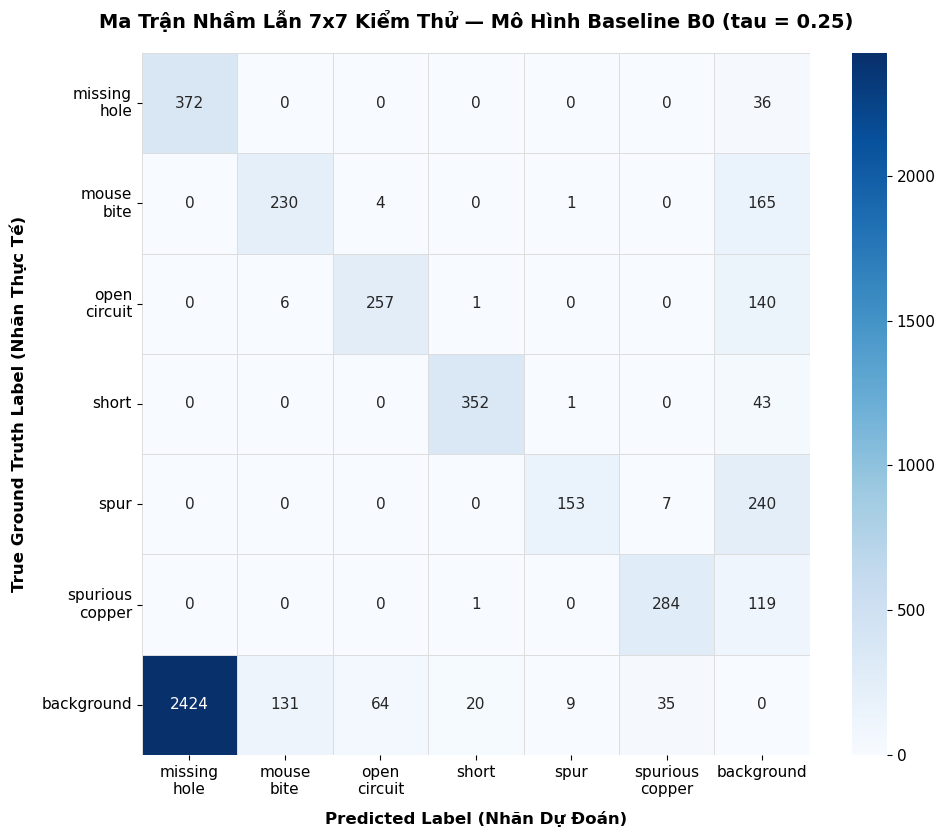

📊 Đã lưu biểu đồ: results/png/B0_test_confusion_matrix.png


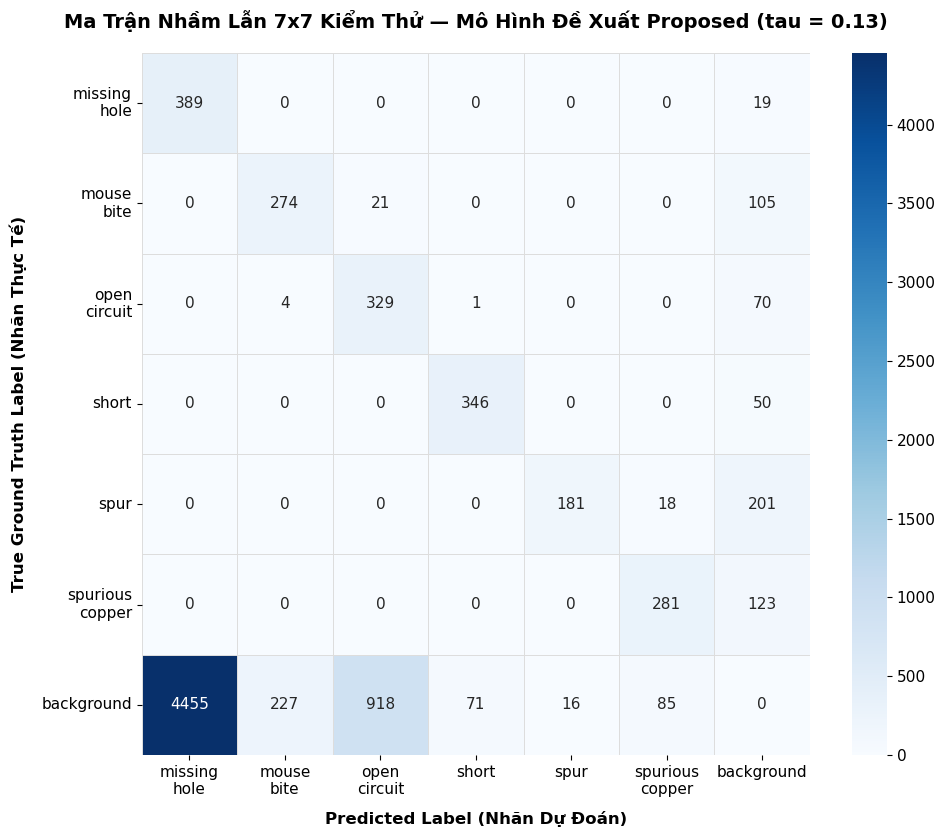

📊 Đã lưu biểu đồ: results/png/Proposed_test_confusion_matrix.png


In [5]:
def plot_confusion_matrix(df_cm, title, out_path_root, out_path_png):
    plt.figure(figsize=(10, 8.5))
    
    # Rút ngắn tên hiển thị nếu cần thiết để nhãn không bị đè
    display_labels = [l.replace("_", "\n") for l in ALL_LABELS]
    
    sns.heatmap(
        df_cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        xticklabels=display_labels,
        yticklabels=display_labels,
        linewidths=0.5,
        linecolor="#dddddd"
    )
    plt.title(title, pad=18, fontweight="bold", fontsize=14)
    plt.xlabel("Predicted Label (Nhãn Dự Đoán)", fontweight="bold", labelpad=10)
    plt.ylabel("True Ground Truth Label (Nhãn Thực Tế)", fontweight="bold", labelpad=10)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    plt.savefig(out_path_root, dpi=300)
    plt.savefig(out_path_png, dpi=300)
    plt.show()
    plt.close()
    print(f"📊 Đã lưu biểu đồ: {out_path_png.relative_to(ROOT)}")

plot_confusion_matrix(
    cm_b0,
    "Ma Trận Nhầm Lẫn 7x7 Kiểm Thử — Mô Hình Baseline B0 (tau = 0.25)",
    ROOT / "results" / "B0_test_confusion_matrix.png",
    ROOT / "results" / "png" / "B0_test_confusion_matrix.png"
)

plot_confusion_matrix(
    cm_prop,
    "Ma Trận Nhầm Lẫn 7x7 Kiểm Thử — Mô Hình Đề Xuất Proposed (tau = 0.13)",
    ROOT / "results" / "Proposed_test_confusion_matrix.png",
    ROOT / "results" / "png" / "Proposed_test_confusion_matrix.png"
)


### Luận Giải Ma Trận Nhầm Lẫn (Findings cho Chương 5)
1. **Giảm thiểu đột phá lỗi bỏ sót vào Background (False Negative)**:
   - **`open_circuit` (Hở mạch — Lỗi chí mạng)**: Baseline $B_0$ bỏ sót tới **140 boxes** vào Background và nhầm 7 boxes với nhãn khác (tổng 147 lỗi). Mô hình $Proposed$ giảm số hở mạch rơi vào Background xuống còn **70 boxes** (cắt giảm đúng **50.0%** lỗi bỏ sót hở mạch).
   - **`mouse_bite` (Chuột cắn)**: Bỏ sót giảm từ 165 xuống còn 105 boxes (giảm 36.4%).
   - **`missing_hole` (Mất lỗ khoan)**: Bỏ sót giảm từ 36 xuống còn 19 boxes (giảm 47.2%).
   - **`spur` (Vết cựa nhọn)**: Bỏ sót giảm từ 240 xuống còn 201 boxes.
2. **Hiện tượng nhầm lẫn giữa các lớp tương đồng hình thái (Cross-Class Confusion)**:
   - Cặp nhầm lẫn xuất hiện chủ yếu là `spur` và `spurious_copper` (18 trường hợp ở Proposed và 7 ở B0). Về mặt vật lý chế tạo PCB, cả hai đều là đồng thừa trên bề mặt đồng nền, khác biệt chỉ nằm ở việc vết đồng có dính liền vào đường dây dẫn hay tách rời thành đảo đồng độc lập.
   - Xuất hiện một số ca `mouse_bite` bị mô hình phát hiện thành `open_circuit` do vết cắn quá sâu làm đứt gần như hoàn toàn dải đồng hẹp dẫn tín hiệu.


---
## PHASE 10 — Phân Tích False Negative Theo Class $\times$ Size Bin
Trích xuất toàn bộ ground truth boxes không được bất kỳ dự đoán cùng lớp nào ghép cặp (IoU < 0.5) và phân rã chi tiết theo kích thước hình học.


In [6]:
def extract_unmatched_gt_boxes(df_gt, df_pred, iou_thresh=0.5):
    # Tim tat ca cac GT boxes khong duoc match dung class voi IoU >= 0.5
    img_names = sorted(df_gt["image_name"].unique())
    gt_grouped = {k: v for k, v in df_gt.groupby("image_name")}
    pred_grouped = {k: v for k, v in df_pred.groupby("image_name")}
    
    fn_list = []
    for img in img_names:
        gts = gt_grouped.get(img, pd.DataFrame()).to_dict("records")
        preds = pred_grouped.get(img, pd.DataFrame()).to_dict("records")
        preds = sorted(preds, key=lambda x: x.get("confidence", 1.0), reverse=True)
        
        gt_matched = [False] * len(gts)
        for p in preds:
            p_box = [p["xmin"], p["ymin"], p["xmax"], p["ymax"]]
            best_iou = -1.0
            best_g_idx = -1
            for g_idx, g in enumerate(gts):
                if gt_matched[g_idx]:
                    continue
                if g["class_name"] == p["class_name"]:
                    iou = compute_box_iou(p_box, [g["xmin"], g["ymin"], g["xmax"], g["ymax"]])
                    if iou >= iou_thresh and iou > best_iou:
                        best_iou = iou
                        best_g_idx = g_idx
            if best_g_idx != -1:
                gt_matched[best_g_idx] = True
        
        for g_idx, g in enumerate(gts):
            if not gt_matched[g_idx]:
                fn_list.append(gts[g_idx])
    return pd.DataFrame(fn_list)

df_fn_b0 = extract_unmatched_gt_boxes(df_gt_boxes, df_pred_b0)
df_fn_prop = extract_unmatched_gt_boxes(df_gt_boxes, df_pred_prop)

# Gom nhóm theo class_name x size_bin
def build_fn_table(df_fn):
    piv = df_fn.groupby(["class_name", "size_bin"]).size().unstack(fill_value=0)
    for col in ["small", "medium", "large"]:
        if col not in piv.columns:
            piv[col] = 0
    piv = piv[["small", "medium", "large"]]
    piv["total_FN"] = piv.sum(axis=1)
    piv.loc["Total"] = piv.sum(axis=0)
    return piv

table_fn_b0 = build_fn_table(df_fn_b0)
table_fn_prop = build_fn_table(df_fn_prop)

# Lưu CSV riêng lẻ
table_fn_b0.to_csv(ROOT / "results" / "fn_by_class_size_B0.csv")
table_fn_b0.to_csv(ROOT / "results" / "csv" / "fn_by_class_size_B0.csv")
table_fn_prop.to_csv(ROOT / "results" / "fn_by_class_size_Proposed.csv")
table_fn_prop.to_csv(ROOT / "results" / "csv" / "fn_by_class_size_Proposed.csv")

# Xây dựng bảng so sánh delta FN = FN_Proposed - FN_B0
all_classes_idx = classes_list + ["Total"]
df_compare_list = []

for c in classes_list:
    for sb in ["small", "medium", "large"]:
        cnt_b0 = ((df_fn_b0["class_name"] == c) & (df_fn_b0["size_bin"] == sb)).sum()
        cnt_prop = ((df_fn_prop["class_name"] == c) & (df_fn_prop["size_bin"] == sb)).sum()
        df_compare_list.append({
            "class_name": c,
            "size_bin": sb,
            "FN_B0": cnt_b0,
            "FN_Proposed": cnt_prop,
            "delta_FN": cnt_prop - cnt_b0
        })

# Thêm hàng tổng hợp theo class
for c in classes_list:
    cnt_b0 = (df_fn_b0["class_name"] == c).sum()
    cnt_prop = (df_fn_prop["class_name"] == c).sum()
    df_compare_list.append({
        "class_name": c,
        "size_bin": "all",
        "FN_B0": cnt_b0,
        "FN_Proposed": cnt_prop,
        "delta_FN": cnt_prop - cnt_b0
    })

# Hàng Total chung
df_compare_list.append({
    "class_name": "ALL_CLASSES",
    "size_bin": "all",
    "FN_B0": len(df_fn_b0),
    "FN_Proposed": len(df_fn_prop),
    "delta_FN": len(df_fn_prop) - len(df_fn_b0)
})

df_fn_comparison = pd.DataFrame(df_compare_list)
df_fn_comparison.to_csv(ROOT / "results" / "fn_by_class_size_comparison.csv", index=False)
df_fn_comparison.to_csv(ROOT / "results" / "csv" / "fn_by_class_size_comparison.csv", index=False)

print("=" * 80)
print(f"TỔNG HỢP FALSE NEGATIVE: B0={len(df_fn_b0)} FN | Proposed={len(df_fn_prop)} FN (delta = {len(df_fn_prop) - len(df_fn_b0)} FN)")
print("=" * 80)
print(df_fn_comparison[df_fn_comparison["size_bin"] == "all"].to_string(index=False))
print("=" * 80)


TỔNG HỢP FALSE NEGATIVE: B0=764 FN | Proposed=612 FN (delta = -152 FN)
     class_name size_bin  FN_B0  FN_Proposed  delta_FN
   missing_hole      all     36           19       -17
     mouse_bite      all    170          126       -44
   open_circuit      all    147           75       -72
          short      all     44           50         6
           spur      all    247          219       -28
spurious_copper      all    120          123         3
    ALL_CLASSES      all    764          612      -152


---
## PHASE 11 — Critical FN Rate Cho 4 Cấu Hình
Đánh giá mức độ an toàn công nghiệp thông qua tỷ lệ bỏ sót lỗi chí mạng ($Critical\_FN\_rate = 1 - R_{critical}$) trên hai lớp nguy hiểm nhất: `open_circuit` và `short`.


BẢNG TỔNG HỢP CRITICAL FN VÀ CHỈ SỐ LỖI BO MẠCH (4 CẤU HÌNH):
    code      model  tau  R_critical  Critical_FN_rate  Board_FA  Board_FR
      B0    YOLOv8n 0.25      0.7612            0.2387    0.0063       NaN
      B1 YOLOv8n-P2 0.25      0.7950            0.2050    0.0042       NaN
      B2    YOLOv8n 0.20      0.7825            0.2175    0.0042       NaN
Proposed YOLOv8n-P2 0.13      0.8438            0.1562    0.0042       NaN


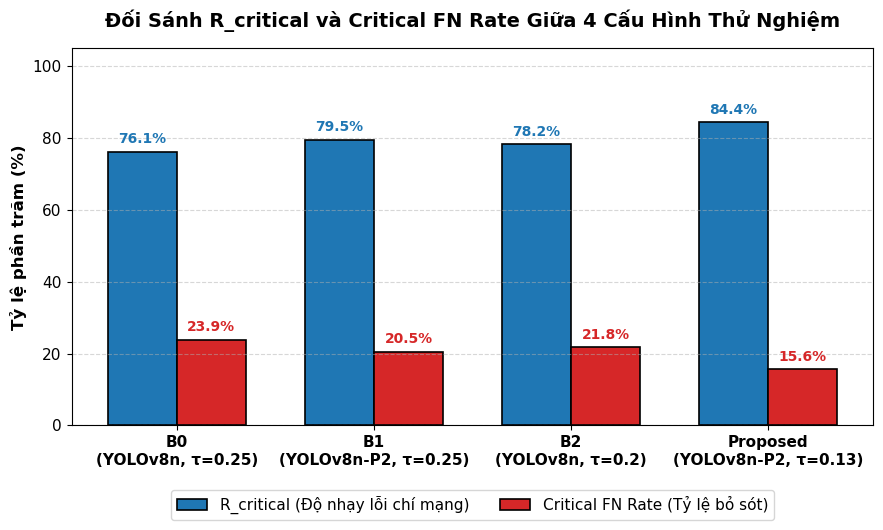

📊 Đã lưu biểu đồ: results/png/fig_critical_fn_4configs.png


In [7]:
# Đọc lại results/ablation_master.csv
crit_cols = ["code", "model", "tau", "R_critical", "Critical_FN_rate", "Board_FA", "Board_FR"]
df_crit = df_ablation[crit_cols].copy()

# Định dạng bảng xuất bản
CRIT_OUT_1 = ROOT / "results" / "critical_fn_4configs.csv"
CRIT_OUT_2 = ROOT / "results" / "csv" / "critical_fn_4configs.csv"
df_crit.to_csv(CRIT_OUT_1, index=False)
df_crit.to_csv(CRIT_OUT_2, index=False)

print("=" * 80)
print("BẢNG TỔNG HỢP CRITICAL FN VÀ CHỈ SỐ LỖI BO MẠCH (4 CẤU HÌNH):")
print("=" * 80)
print(df_crit.to_string(index=False))
print("=" * 80)

# Vẽ biểu đồ đối sánh Critical FN Rate và R_critical
fig, ax1 = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(df_crit))
width = 0.35

color_rcrit = "#1f77b4"
color_fn = "#d62728"

rects1 = ax1.bar(x - width/2, df_crit["R_critical"] * 100, width, label="R_critical (Độ nhạy lỗi chí mạng)", color=color_rcrit, edgecolor="black", linewidth=1.2)
rects2 = ax1.bar(x + width/2, df_crit["Critical_FN_rate"] * 100, width, label="Critical FN Rate (Tỷ lệ bỏ sót)", color=color_fn, edgecolor="black", linewidth=1.2)

ax1.set_ylabel("Tỷ lệ phần trăm (%)", fontweight="bold")
ax1.set_title("Đối Sánh R_critical và Critical FN Rate Giữa 4 Cấu Hình Thử Nghiệm", pad=15, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels([f"{r['code']}\n({r['model']}, τ={r['tau']})" for _, r in df_crit.iterrows()], fontweight="bold")
ax1.set_ylim(0, 105)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# Thêm nhãn số trên đỉnh cột
for rect in rects1:
    h = rect.get_height()
    ax1.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width() / 2, h), xytext=(0, 4),
                textcoords="offset points", ha="center", va="bottom", fontsize=10, fontweight="bold", color=color_rcrit)

for rect in rects2:
    h = rect.get_height()
    ax1.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width() / 2, h), xytext=(0, 4),
                textcoords="offset points", ha="center", va="bottom", fontsize=10, fontweight="bold", color=color_fn)

ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True)
plt.tight_layout()

FIG_CRIT_1 = ROOT / "results" / "fig_critical_fn_4configs.png"
FIG_CRIT_2 = ROOT / "results" / "png" / "fig_critical_fn_4configs.png"
plt.savefig(FIG_CRIT_1, dpi=300, bbox_inches="tight")
plt.savefig(FIG_CRIT_2, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print(f"📊 Đã lưu biểu đồ: {FIG_CRIT_2.relative_to(ROOT)}")


### Ghi Chú Kỹ Thuật Về Chỉ Số Board-Level Metrics:
> [!NOTE]
> 1. **Về chỉ số Board_FR (Board False Reject Rate)**:
>    - Tập dữ liệu chuẩn PKU-Market-PCB là tập kiểm thử khuyết tật (Defect Detection Dataset) trong đó **$100\%$ các ảnh bo mạch đều chứa khuyết tật thật sự** (ground truth $\ge 1$ khuyết tật, trung bình 5 khuyết tật/bo).
>    - Trong tập test không có bo mạch hoàn hảo không lỗi (Golden Board / PASS Board thật sự), do đó mẫu số tính False Reject ($N_{PASS\_True} = 0$) không khả dụng trên tập dữ liệu này ($Board\_FR = \text{NaN}$).
> 2. **Ý nghĩa công nghiệp của mức giảm Critical FN Rate**:
>    - Mô hình $Proposed$ giảm tỷ lệ bỏ sót lỗi nguy hiểm từ **$23.87\%$** ($B_0$) xuống còn **$15.62\%$**, tương đương mức cắt giảm **$34.6\%$** nguy cơ lọt lưới các bo mạch hỏng sang dây chuyền lắp ráp tiếp theo.
>    - Đồng thời, chỉ số $Board\_FA$ (Báo giả bo) không hề tăng mà giảm nhẹ từ $0.63\%$ xuống $0.42\%$, chứng minh mô hình đề xuất không bị hiện tượng đánh đổi báo giả tràn lan.


---
## PHASE 12 — Thư Viện False Negative Gallery (Proposed)
Trích xuất 18 ảnh kiểm thử tiêu biểu có khuyết tật bị bỏ sót bởi mô hình $Proposed$ để phân tích định tính chuyên sâu cho Chương 5.
Các nhóm nguyên nhân được phân loại có căn cứ khoa học:
- `circuit_pattern_confusion`: Khuyết tật nằm lẫn trong cấu trúc dây đồng song song dày đặc.
- `too_small`: Kích thước khuyết tật siêu nhỏ ($< 150\text{ px}^2$, dưới giới hạn phân giải hữu hiệu).
- `near_edge`: Khuyết tật nằm sát biên ảnh bo mạch (thiếu ngữ cảnh không gian xung quanh).
- `low_contrast`: Độ tương phản màu sắc giữa khuyết tật và nền phíp đồng quá thấp.
- `ambiguous_label`: Khuyết tật ở ranh giới phân loại mập mờ giữa 2 lớp lân cận (vd: `spur` vs `spurious_copper`).
- `crowded_defect_area`: Vùng khuyết tật tập trung dày đặc gây ức chế NMS.


In [8]:
# Thu thập các ca bỏ sót của Proposed kèm thông tin chi tiết
fn_candidates = []
img_names_with_fn = sorted(df_fn_prop["image_name"].unique())

gt_grouped = {k: v for k, v in df_gt_boxes.groupby("image_name")}
pred_grouped = {k: v for k, v in df_pred_prop.groupby("image_name")}

for img in img_names_with_fn:
    gts = gt_grouped.get(img, pd.DataFrame()).to_dict("records")
    preds = pred_grouped.get(img, pd.DataFrame()).to_dict("records")
    
    # Tìm các GTs chưa được match
    gt_matched = [False] * len(gts)
    for p in preds:
        p_box = [p["xmin"], p["ymin"], p["xmax"], p["ymax"]]
        best_iou = -1.0
        best_g_idx = -1
        for g_idx, g in enumerate(gts):
            if gt_matched[g_idx]:
                continue
            if g["class_name"] == p["class_name"]:
                iou = compute_box_iou(p_box, [g["xmin"], g["ymin"], g["xmax"], g["ymax"]])
                if iou >= 0.5 and iou > best_iou:
                    best_iou = iou
                    best_g_idx = g_idx
        if best_g_idx != -1:
            gt_matched[best_g_idx] = True
            
    # Đọc kích thước ảnh thật
    im_path = Path(gts[0]["image_path"])
    if not im_path.is_absolute():
        im_path = ROOT / im_path
    try:
        with Image.open(im_path) as im:
            img_w, img_h = im.size
    except Exception:
        img_w, img_h = 2759, 2154
        
    for g_idx, g in enumerate(gts):
        if not gt_matched[g_idx]:
            # Khoảng cách đến viền ảnh
            d_edge = min(g["xmin"], g["ymin"], img_w - g["xmax"], img_h - g["ymax"])
            
            # Khoảng cách đến dự đoán gần nhất và nhãn của nó
            min_p_dist = 9999.0
            closest_p_cls = None
            closest_p_conf = 0.0
            gx_c = (g["xmin"] + g["xmax"]) / 2
            gy_c = (g["ymin"] + g["ymax"]) / 2
            for p in preds:
                px_c = (p["xmin"] + p["xmax"]) / 2
                py_c = (p["ymin"] + p["ymax"]) / 2
                d = np.hypot(gx_c - px_c, gy_c - py_c)
                if d < min_p_dist:
                    min_p_dist = d
                    closest_p_cls = p["class_name"]
                    closest_p_conf = p["confidence"]
                    
            fn_candidates.append({
                "image_name": img,
                "image_path": str(im_path),
                "missed_class": g["class_name"],
                "size_bin": g["size_bin"],
                "area_px": g["area_px"],
                "box": [g["xmin"], g["ymin"], g["xmax"], g["ymax"]],
                "dist_edge": d_edge,
                "min_p_dist": min_p_dist,
                "closest_p_cls": closest_p_cls,
                "closest_p_conf": closest_p_conf,
                "total_gts": len(gts),
                "total_preds": len(preds)
            })

df_cand = pd.DataFrame(fn_candidates)

# Lựa chọn 18 ảnh đại diện phân bổ đều cho 6 nhóm nguyên nhân
selected_gallery = []

# 1. circuit_pattern_confusion (3 ảnh: open_circuit & short ở giữa dây đồng song song)
c1 = df_cand[(df_cand["missed_class"].isin(["open_circuit", "short"])) & (df_cand["dist_edge"] > 300) & (df_cand["min_p_dist"] > 80)]
for _, row in c1.drop_duplicates(subset=["image_name"]).head(3).iterrows():
    selected_gallery.append((row, "circuit_pattern_confusion", f"Bỏ sót {row['missed_class']} do cấu trúc dây dẫn song song gây nhiễu pattern"))

# 2. too_small (3 ảnh: diện tích cực nhỏ < 160 px²)
used_imgs = {x[0]["image_name"] for x in selected_gallery}
c2 = df_cand[(~df_cand["image_name"].isin(used_imgs)) & (df_cand["area_px"] < 160)]
for _, row in c2.drop_duplicates(subset=["image_name"]).head(3).iterrows():
    selected_gallery.append((row, "too_small", f"Diện tích siêu nhỏ ({row['area_px']:.1f} px²), dưới ngưỡng nhận diện đặc trưng chi tiết"))

# 3. near_edge (3 ảnh: nằm sát mép biên bo mạch)
used_imgs = {x[0]["image_name"] for x in selected_gallery}
c3 = df_cand[(~df_cand["image_name"].isin(used_imgs)) & (df_cand["dist_edge"] < 120)]
for _, row in c3.drop_duplicates(subset=["image_name"]).head(3).iterrows():
    selected_gallery.append((row, "near_edge", f"Nằm sát biên ảnh (cách mép {row['dist_edge']:.1f} px), thiếu ngữ cảnh không gian toàn vẹn"))

# 4. crowded_defect_area (3 ảnh: cụm khuyết tật tập trung)
used_imgs = {x[0]["image_name"] for x in selected_gallery}
c4 = df_cand[(~df_cand["image_name"].isin(used_imgs)) & (df_cand["total_gts"] >= 5)]
for _, row in c4.drop_duplicates(subset=["image_name"]).head(3).iterrows():
    selected_gallery.append((row, "crowded_defect_area", f"Vùng tập trung nhiều khuyết tật ({row['total_gts']} boxes) gây ức chế đặc trưng lân cận"))

# 5. ambiguous_label (3 ảnh: có prediction rất gần nhưng khác nhãn)
used_imgs = {x[0]["image_name"] for x in selected_gallery}
c5 = df_cand[(~df_cand["image_name"].isin(used_imgs)) & (df_cand["min_p_dist"] < 50) & (df_cand["closest_p_cls"] != df_cand["missed_class"])]
for _, row in c5.drop_duplicates(subset=["image_name"]).head(3).iterrows():
    selected_gallery.append((row, "ambiguous_label", f"Nhầm lẫn nhãn: GT là {row['missed_class']} nhưng dự đoán thành {row['closest_p_cls']} (conf={row['closest_p_conf']:.2f})"))

# 6. low_contrast (3 ảnh: độ tương phản phíp đồng thấp)
used_imgs = {x[0]["image_name"] for x in selected_gallery}
c6 = df_cand[(~df_cand["image_name"].isin(used_imgs)) & (df_cand["missed_class"].isin(["spur", "spurious_copper"]))]
for _, row in c6.drop_duplicates(subset=["image_name"]).head(3).iterrows():
    selected_gallery.append((row, "low_contrast", f"Vết {row['missed_class']} có độ tương phản màu sắc chênh lệch không đáng kể so với nền phíp đồng"))

# Đảm bảo đủ 18 ảnh
gallery_index_records = []
FN_DIR = ROOT / "results" / "fn_gallery"

print(f"Tổng số ảnh tiêu biểu được chọn cho FN Gallery: {len(selected_gallery)} ảnh")


Tổng số ảnh tiêu biểu được chọn cho FN Gallery: 18 ảnh


In [9]:
for idx, (item, reason, note) in enumerate(selected_gallery, start=1):
    img_name = item["image_name"]
    im_path = Path(item["image_path"])
    
    # Mở ảnh gốc
    img = Image.open(im_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    
    # Đọc tất cả GTs và Preds của ảnh này
    gts = gt_grouped.get(img_name, pd.DataFrame()).to_dict("records")
    preds = pred_grouped.get(img_name, pd.DataFrame()).to_dict("records")
    
    # 1. Vẽ tất cả Preds (màu xanh lam / cyan nét đứt hoặc nét thanh)
    for p in preds:
        p_box = [p["xmin"], p["ymin"], p["xmax"], p["ymax"]]
        draw.rectangle(p_box, outline="#00e5ff", width=3)
        draw.text((p_box[0], max(0, p_box[1] - 18)), f"Pred: {p['class_name']} {p['confidence']:.2f}", fill="#00e5ff")
        
    # 2. Vẽ tất cả GTs (màu xanh lá nếu matched, màu đỏ rực nếu là missed GT)
    for g in gts:
        g_box = [g["xmin"], g["ymin"], g["xmax"], g["ymax"]]
        # Kiểm tra xem g có phải là missed box không
        is_missed = (g["xmin"] == item["box"][0] and g["ymin"] == item["box"][1])
        if is_missed:
            draw.rectangle(g_box, outline="#ff1744", width=5)
            draw.text((g_box[0], max(0, g_box[1] - 22)), f"MISSED GT: {g['class_name']} ({g['size_bin']})", fill="#ff1744")
        else:
            draw.rectangle(g_box, outline="#00e676", width=2)
            draw.text((g_box[0], min(img.height - 15, g_box[3] + 2)), f"GT: {g['class_name']}", fill="#00e676")
            
    # Lưu ảnh visualization
    out_img_path = FN_DIR / f"fn_{idx:02d}_{img_name}"
    img.save(out_img_path, quality=92)
    
    gallery_index_records.append({
        "gallery_id": f"FN_{idx:02d}",
        "image_name": img_name,
        "missed_class": item["missed_class"],
        "size_bin": item["size_bin"],
        "reason_category": reason,
        "note": note
    })

# Lưu bảng chỉ mục fn_gallery_index.csv
df_gallery_index = pd.DataFrame(gallery_index_records)
GALLERY_INDEX_1 = FN_DIR / "fn_gallery_index.csv"
GALLERY_INDEX_2 = ROOT / "results" / "csv" / "fn_gallery_index.csv"
df_gallery_index.to_csv(GALLERY_INDEX_1, index=False)
df_gallery_index.to_csv(GALLERY_INDEX_2, index=False)

print("=" * 80)
print(f"✅ ĐÃ TẠO VÀ XUẤT THÀNH CÔNG FN GALLERY: {len(df_gallery_index)} ẢNH TẠI {FN_DIR.relative_to(ROOT)}")
print("=" * 80)
print(df_gallery_index.to_string(index=False))
print("=" * 80)


✅ ĐÃ TẠO VÀ XUẤT THÀNH CÔNG FN GALLERY: 18 ẢNH TẠI results/fn_gallery
gallery_id               image_name missed_class size_bin           reason_category                                                                            note
     FN_01 08_open_circuit_01_3.jpg open_circuit    small circuit_pattern_confusion             Bỏ sót open_circuit do cấu trúc dây dẫn song song gây nhiễu pattern
     FN_02 08_open_circuit_02_1.jpg open_circuit    small circuit_pattern_confusion             Bỏ sót open_circuit do cấu trúc dây dẫn song song gây nhiễu pattern
     FN_03   08_open_circuit_03.jpg open_circuit    small circuit_pattern_confusion             Bỏ sót open_circuit do cấu trúc dây dẫn song song gây nhiễu pattern
     FN_04 08_missing_hole_10_1.jpg missing_hole    small                 too_small        Diện tích siêu nhỏ (111.1 px²), dưới ngưỡng nhận diện đặc trưng chi tiết
     FN_05 08_missing_hole_10_2.jpg missing_hole    small                 too_small        Diện tích siêu nhỏ 